# 1. Vectors 2

## 1A. Vector sets

A collection of vectors is called a _set_. Vector sets are indicated using capital italics letters, like $\mathit{S}$ or $\mathit{V}$.
$$
    \mathit{V} = \{ \mathbf{v}_1, \ldots, \mathbf{v}_n \} 
$$

## 1B. Linera weighted combination

_Weighted combination_ is a way of mixing information from multiple variables, with some variables contributing more than others, i.e., take some set of vectors, multiply each vector by a scalar, and add them to produce a single vector.
$$
    \mathbf{w} = \lambda_n \mathbf{v}_1 + \lambda_n \mathbf{v}_n + \ldots + \lambda_n \mathbf{v}_n = \sum_{i=1}^n \lambda_i \mathbf{v}_i
$$

In [3]:
import numpy as np

l1 = 1
l2 = 2
l3 = -3

v1 = np.array([4, 5, 1])
v2 = np.array([-4, 0, -4])
v3 = np.array([1, 3, 2])

l1*v1 + l2*v2 + l3*v3

array([ -7,  -4, -13])

Applications:
* The predicted data from statistical model are created by taking the linear weighted combination or regressors (predictor variables) and coefficients (scalars) that are computed via the least squares algorithm.
* In dimension-reduction procedures such as principal components analysis, each component is derived as a linear weighted combination of the data channels of the data, with the weights selected t omaximize the variance of the component.
* In artificial neural networks the weights are learned by minimizing a cost function, which is typically the difference between the model prediction and the real-world target variable.

## 1C. Linear independence

A set of vectors is _linearly dependent_ if at least one vector in the set can be expressed as a linear weighted combination of other vectors in that set. And thus, a set of vectors is _linearly independent_ if no vector can be expressed as a lineaer weighted combination of other vectors in the set.

To determine linear independence is to create a matrix from the vector set, compute the rank of the matrix, and compare the rank to the smaller of the number of rows or columns (see chapter 5).


### 1C1. The math of linear independence

It can be found some linear weighted combination of the vectors in the set to produce the zeros vector. 
$$
    \mathbf{0} = \sum_{i=1}^n \lambda_i \mathbf{v}_i, \quad \lambda \in \mathbb{R}
$$

Rewriting the previous equation as follows, i.e., no individual vector has the privileged position of being the "dependent vector".
$$
    \lambda_j \mathbf{v}_j = \sum_{i=1,i\neq j}^n \lambda_i \mathbf{v}_i, \quad \lambda \in \mathbb{R}
$$

As trivial solutions involving zeros are often ignored in linear algebra, then using $\lambda_1$ as a denominator gives:
$$
    \mathbf{0} = \mathbf{v}_1 + \sum_{i=2}^n \frac{\lambda_i}{\lambda_1} \mathbf{v}_i, \quad \lambda \in \mathbb{R}, \lambda_1 \neq 0
$$

The reason for the linearity constraint, when thinking about nonlinear, is that these transformations are wanted to be expressed as amtrix multiplication, which is a linear operation.

## 1D. Subspace and Span

A _subspace_ uses infinity of possible ways to linearly combine the vectors in the set, i.e., for some (finite) set of vectors, the infinite number of ways to linearly combine them, using the same vectors but different numerical values for the weights, creates a _vector subspace_. Where the mechanism of combining all possible linear weighted combinations is called the _span_ of the vector set. For example, for a set with one vector, that simply means all possible __scaled versions__ of that vector.

To be cleared, span is the mechanism of creating a subspace.



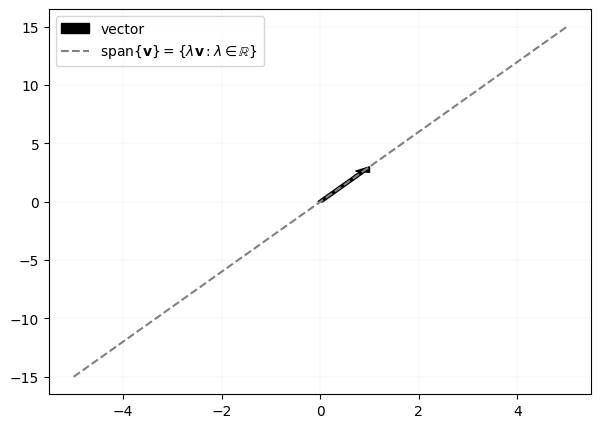

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

V = np.array([1,3]) # This is a vector set of one vector

lambda_v = np.array([-5, 5])  # scalar range, stands in for (-inf, +inf)

plt.figure(figsize=(7,5))

plt.arrow(0, 0, V[0], V[1], color='k', head_width=0.3, width=0.1, length_includes_head=True, label='vector')
plt.plot(lambda_v*V[0], lambda_v*V[1], color='gray', linestyle='--', label=r'span$\{\mathbf{v}\}=\{\lambda \mathbf{v}: \lambda \in \mathbb{R}\}$')

plt.grid(linestyle='--', linewidth=0.1)
plt.legend()
plt.savefig('Figure_03_01.png', dpi=300)
plt.show()

The following example shows a vector set compounded by $\mathbf{v}$ and $\mathbf{w}$ both $\in \mathbb{R}^3$ which subspace that they span is a 2D plane in the 3D space. 

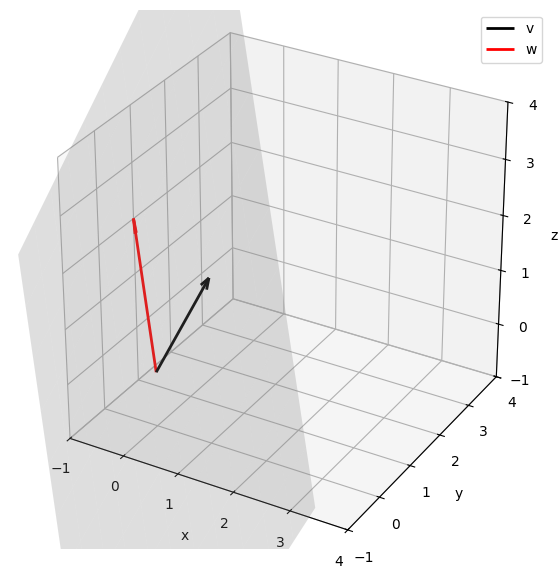

In [6]:
import matplotlib.pyplot as plt
import numpy as np

v = np.array([1, 0, 2])
w = np.array([-1, 1, 2])

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection='3d')

# span{v, w} = {s*v + t*w}
s, t = np.meshgrid(np.linspace(-2, 2, 12), np.linspace(-2, 2, 12))
P = s[..., None] * v + t[..., None] * w      # shape (12, 12, 3)
ax.plot_surface(P[..., 0], P[..., 1], P[..., 2],
                color='gray', alpha=0.25, edgecolor='none')

for vec, colour, labl in [(v, 'k', 'v'), (w, 'r', 'w')]:
    ax.quiver(0, 0, 0, *vec, color=colour, label=labl,
              arrow_length_ratio=0.1, linewidth=2)

ax.set(xlim=[-1, 4], ylim=[-1, 4], zlim=[-1, 4],
       xlabel='x', ylabel='y', zlabel='z')
ax.set_box_aspect([1, 1, 1])
ax.legend()
plt.savefig('Figure_03_02.png',dpi=300)
plt.show()


The following example shows a vector set compounded by $\mathbf{v}$ and $\mathbf{w}$ both $\in \mathbb{R}^3$ which subspace that they span is a 1D line in the 3D space because the two vectors are redundant. 

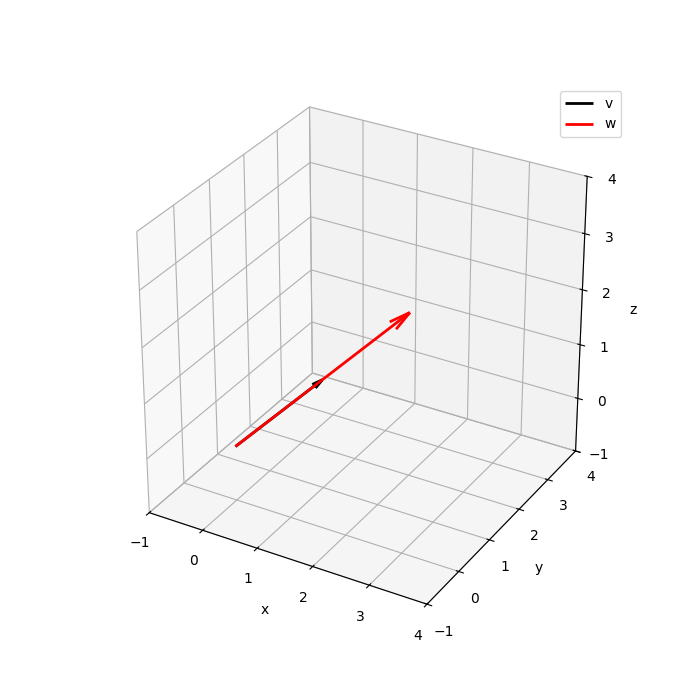

In [7]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np

v = np.array([1, 1, 1])
w = np.array([2, 2, 2])

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection='3d')

# span{v, w} = {s*v + t*w}
s, t = np.meshgrid(np.linspace(-4, 4, 12), np.linspace(-4, 4, 12))
P = s[..., None] * v + t[..., None] * w      # shape (12, 12, 3)
ax.plot_surface(P[..., 0], P[..., 1], P[..., 2],
                color='gray', alpha=0.25, edgecolor='none')

for vec, colour, labl in [(v, 'k', 'v'), (w, 'r', 'w')]:
    ax.quiver(0, 0, 0, *vec, color=colour, label=labl,
              arrow_length_ratio=0.1, linewidth=2)

ax.set(xlim=[-1, 4], ylim=[-1, 4], zlim=[-1, 4],
       xlabel='x', ylabel='y', zlabel='z')
ax.set_box_aspect([1, 1, 1])
ax.legend()
plt.savefig('Figure_03_03.png',dpi=300)
plt.show()

The dimensionality of the subspace spanned by a set of vectors is the smallest number of vectors that forms a linearly independent set (see chapter 6). 


## 1E. Basis

A _basis_ is a set of rulers for measuring a space. The most common basis set is the Cartesian axis (XY plane). A vector set can be a basis for a subspace if it (1) spans that subspace and (2) is linearly independent. A major goal in data science is to discover the best basis set to describe datasets or to solve problems.

## 1F. Exercises

### 1F1. Linear weighted combination

In [8]:
import random

size_v = random.randint(1,10)
v = [random.randint(-10, 10) for i in range(size_v)]
lambda_v =  [random.randint(-10, 10) for i in range(size_v)]

w = [random.randint(-10, 10) for i in range(size_v)]
lambda_w =  [random.randint(-10, 10) for i in range(size_v)]

output = np.zeros(size_v)
for idx in range(size_v):
    output[idx] = lambda_v[idx] * v[idx] + lambda_w[idx] * w[idx]
    
print(f'v\t {np.asarray(lambda_v)*np.asarray(v)}\n w\t {np.asarray(lambda_w)*np.asarray(w)}\n output\t {output}')

v	 [-36 -50  -4]
 w	 [100 -21  -7]
 output	 [ 64. -71. -11.]


### 1F2. $\lambda \in \mathbb{R}^4$ and $V \in \mathbb{R}^3$

In [9]:
v = [random.randint(-10, 10) for i in range(3)]
lambda_v =  [random.randint(-10, 10) for i in range(4)]

w = [random.randint(-10, 10) for i in range(3)]
lambda_w =  [random.randint(-10, 10) for i in range(4)]

output = np.zeros(3)
for idx in range(3):
    output[idx] = lambda_v[idx] * v[idx] + lambda_w[idx] * w[idx]
    
print(f'v\t {np.asarray(lambda_v)*np.asarray(v)}\n w\t {np.asarray(lambda_w)*np.asarray(w)}\n output\t {output}')

ValueError: operands could not be broadcast together with shapes (4,) (3,) 

### 1F3. Random points in subspaces

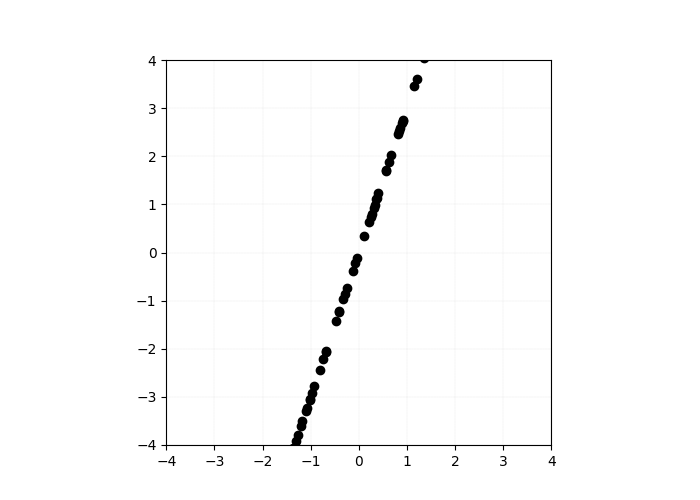

In [10]:
n = 100
basis_vector_V = np.array([1, 3])
scalars = np.random.uniform(-4, 4, size=n)

plt.figure(figsize=(7,5))
for s in scalars:
    point = s * basis_vector_V
    plt.plot(point[0], point[1], 'ko')

plt.grid(linestyle='--', linewidth=0.1) 
plt.axis('square')
plt.axis([-4,4,-4,4])
plt.savefig('Figure_03_07a.png',dpi=300)
plt.show()

In [13]:
n = 100
v = np.array([3, 5, 1])
w = np.array([0, 2, 2])
scalars = np.random.uniform(-4, 4, size=(n,2))

points = np.zeros((n,3))
for i in range(n):
    points[i,:] = scalars[i,0] * v + scalars[i,1] * w

import plotly.graph_objects as go 
fig = go.Figure( data=[go.Scatter3d(
    x=points[:,0], y=points[:,1], z=points[:,2],
    mode='markers'
)])
fig.update_layout(margin=dict(l=0,r=0,b=0,t=0))
plt.savefig('Figure_03_07b.png',dpi=300)
fig.show()